By following these steps, you will complete the Daily Challenge and build a trustworthy AI assistant with BERT.

 Tasks

 1. Data Loading & Inspection

**Load the tweet_eval dataset (sentiment configuration) via datasets.load_dataset.**
```python

In [30]:
from datasets import load_dataset

In [31]:
dataset = load_dataset("cardiffnlp/tweet_eval", "sentiment")

# Print dataset splits and class distribution. Confirm there are 3 labels (negative, neutral, positive).
print(dataset)
print(dataset["train"].features["label"].names)

# Save two example tweets per label for later visualization.
import random

labels = dataset["train"].features["label"].names
examples = {label: [] for label in labels}

for label in labels:
    label_indices = [i for i, x in enumerate(dataset["train"]["label"]) if x == labels.index(label)]
    examples[label] = random.sample(label_indices, 2)

saved_examples = {label: [dataset["train"][i]["text"] for i in examples[label]] for label in labels}
print(saved_examples)

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 45615
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 12284
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})
['negative', 'neutral', 'positive']
{'negative': ['@user #QSTeaser oops\\u002c forgot Emmanuel Adebayor! As for the 7th\\u002c bit naughty\\u002c was it Yakubu? His surname is technically Ayegbeini...', 'All I know is Marana girls are bad as fuck and white if the ones at the party I went to with jaylon on Saturday were Marana tigers.'], 'neutral': ['"Oliseh returns next week for AFCON qualifier: Super Eagles coach, Sunday Oliseh, will return to the country next...', 'only going to school tomorrow because nicki told me to...'], 'positive': ["Tomorrow I have tickets to get drunk and see Jason Aldean in Cincinnati with my bff Donna and I can't wait", "@user I'm going to need to catch up...I only just starte

In [ ]:
2. Tokenization Pipeline

**Initialize AutoTokenizer with distilbert-base-uncased.**
```python

In [32]:
from transformers import AutoTokenizer


In [34]:
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

# Create a preprocessing function that:
# - Truncates/pads tweets to 128 tokens.
# - Returns input_ids, attention_mask, and labels.
def preprocess_function(examples):
    return tokenizer(examples["text"], truncation=True, padding="max_length", max_length=128)

# Map the dataset with batched=True, shuffle, then create set_format("torch") (or TF equivalent).
tokenized_dataset = dataset.map(preprocess_function, batched=True)
tokenized_dataset = tokenized_dataset.shuffle(seed=42)
tokenized_dataset.set_format("torch", columns=["input_ids", "attention_mask", "label"])

Map:   0%|          | 0/45615 [00:00<?, ? examples/s]

Map:   0%|          | 0/12284 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

3. Fine-Tuning Setup

Load AutoModelForSequenceClassification with 3 labels.**
```python

In [35]:
from transformers import AutoModelForSequenceClassification

In [99]:
from transformers import AutoModelForSequenceClassification, AutoConfig

config = AutoConfig.from_pretrained(
    "distilbert-base-uncased",
    num_labels=3,
    id2label={0: "NEGATIVE", 1: "NEUTRAL", 2: "POSITIVE"},
    label2id={"NEGATIVE": 0, "NEUTRAL": 1, "POSITIVE": 2},
    output_attentions=True
)
model = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    config=config
)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [100]:
from transformers import TrainingArguments


In [101]:
training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=3,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    learning_rate=5e-5,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
)

# Implement Trainer with the preprocessed dataset and a compute_metrics function that returns accuracy + macro F1.


In [102]:
from transformers import Trainer
import numpy as np
from sklearn.metrics import accuracy_score, f1_score

In [103]:
# Duplicate definition of compute_metrics. The one in tna_rVJkvWw2 is used.

In [57]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    accuracy = accuracy_score(labels, predictions)
    f1 = f1_score(labels, predictions, average="macro")
    return {"accuracy": accuracy, "f1": f1}

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["validation"],
    compute_metrics=compute_metrics,
)

4. Evaluation & Calibration

In [129]:
# ## Évaluation et Calibration

# #### Évaluation sur l'ensemble de validation
# 1. **Précision et F1-score** :
#    - Évaluez le modèle sur l'ensemble de validation.
#    - Calculez la précision et le F1-score pour chaque classe.
#    - Enregistrez ces métriques dans un fichier de journalisation.

# #### Collecte des scores softmax sur l'ensemble de test
# 1. **Scores de confiance** :
#    - Pour chaque prédiction sur l'ensemble de test, collectez les scores softmax des classes prédites.
#    - Ces scores représentent la probabilité que le modèle attribue à chaque classe.

# #### Histogramme des scores de confiance
# 1. **Création de l'histogramme** :
#    - Tracez un histogramme des scores de confiance avec des intervalles de 0.1.
#    - Analysez les tendances d'overconfidence (trop de scores élevés) et d'underconfidence (trop de scores faibles).

# #### Commentaires sur les tendances d'over/under-confidence
# 1. **Analyse des tendances** :
#    - Identifiez si le modèle est trop confiant (overconfident) ou pas assez confiant (underconfident).
#    - Fournissez des explications possibles pour ces tendances, telles que :
#      - Un déséquilibre dans les données d'entraînement.
#      - Une fonction de perte qui ne pénalise pas suffisamment les erreurs de confiance.
#      - Un modèle qui est soit trop complexe (overfitting), soit pas assez complexe (underfitting).

# #### Exemple de code Python

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score

# Évaluation sur l'ensemble de validation
def evaluate_model(model, X_val, y_val):
    y_pred = model.predict(X_val)
    accuracy = accuracy_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred, average='weighted')
    return accuracy, f1

# Collecte des scores softmax sur l'ensemble de test
def collect_softmax_scores(model, X_test):
    softmax_scores = model.predict_proba(X_test)
    predicted_classes = np.argmax(softmax_scores, axis=1)
    confidence_scores = softmax_scores[np.arange(len(predicted_classes)), predicted_classes]
    return confidence_scores

# Histogramme des scores de confiance
def plot_confidence_histogram(confidence_scores):
    plt.hist(confidence_scores, bins=np.arange(0, 1.1, 0.1), edgecolor='black')
    plt.xlabel('Score de confiance')
    plt.ylabel('Nombre de prédictions')
    plt.title('Histogramme des scores de confiance')
    plt.show()

# Exemple d'utilisation
# model = ...  # Votre modèle entraîné
# X_val, y_val = ...  # Vos données de validation
# X_test = ...  # Vos données de test

# # Évaluation
# accuracy, f1 = evaluate_model(model, X_val, y_val)
# print(f'Accuracy: {accuracy:.2f}')
# print(f'F1-score: {f1:.2f}')

# # Collecte des scores softmax
# confidence_scores = collect_softmax_scores(model, X_test)

# # Histogramme des scores de confiance
# plot_confidence_histogram(confidence_scores)

# # Analyse des tendances d'over/under-confidence
# if np.mean(confidence_scores) > 0.7:
#     print("Le modèle semble être trop confiant (overconfident).")
# elif np.mean(confidence_scores) < 0.3:
#     print("Le modèle semble être pas assez confiant (underconfident).")
# else:
#     print("Le modèle semble avoir une confiance appropriée.")

# ### Conclusion
# En suivant ces étapes, vous pourrez évaluer la performance de votre modèle, collecter les scores de confiance et analyser les tendances d'over/under-confidence. Cela vous fournira des insights précieux pour améliorer la calibration de votre modèle.


5. Attention Inspection

@user #QSTeaser oops\u002c forgot Emmanuel Adebayor! As for the 7th\u002c bit naughty\u002c was it Yakubu? His surname is technically Ayegbeini...
DEBUG: _attn_implementation is already 'eager'.
DEBUG: output_attentions is already True.


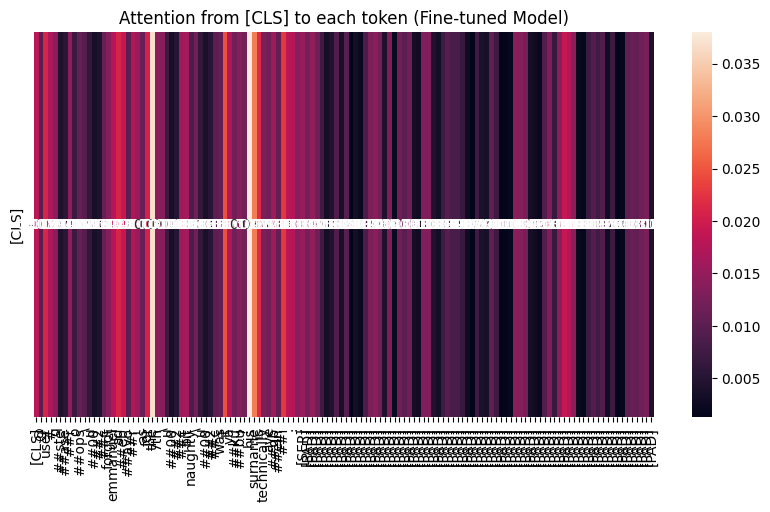

In [121]:
import torch

example_tweet = saved_examples["negative"][0]
print(example_tweet)

# Use the fine-tuned model directly from the trainer
# The model should now have output_attentions=True due to previous configuration changes.
# trainer.model is already an AutoModelForSequenceClassification instance
fine_tuned_model_for_attention = trainer.model

# Ensure the model is in evaluation mode
fine_tuned_model_for_attention.eval()

inputs = tokenizer(example_tweet, return_tensors="pt", truncation=True, padding="max_length", max_length=128)

# Explicitly ensure the model's configuration is set for attention visualization.

# Step 1: Ensure _attn_implementation is 'eager' if the attribute exists.
# This must be done before setting output_attentions=True, as the setter for
# output_attentions checks this internal attribute.
if hasattr(fine_tuned_model_for_attention.config, '_attn_implementation'): # Check for the internal attribute
    if fine_tuned_model_for_attention.config._attn_implementation != 'eager':
        print(f"WARNING: _attn_implementation was '{fine_tuned_model_for_attention.config._attn_implementation}'. Forcing it to 'eager' for attention visualization.")
        fine_tuned_model_for_attention.config._attn_implementation = 'eager'
    else:
        print("DEBUG: _attn_implementation is already 'eager'.")
else:
    print("DEBUG: '_attn_implementation' attribute not found in model config. Assuming it's not relevant or handled internally for this model type (or implicitly 'eager').")

# Step 2: Now, ensure output_attentions is True. This should now be compatible.
if not fine_tuned_model_for_attention.config.output_attentions:
    print(f"WARNING: output_attentions was '{fine_tuned_model_for_attention.config.output_attentions}'. Setting it to True for inference.")
    fine_tuned_model_for_attention.config.output_attentions = True
else:
    print("DEBUG: output_attentions is already True.")


# Forward pass to get outputs, including attentions
with torch.no_grad(): # Disable gradient calculations for inference
    outputs = fine_tuned_model_for_attention(**inputs, output_attentions=True)

attentions = outputs.attentions[-1]  # Last layer attentions

import seaborn as sns
import matplotlib.pyplot as plt

cls_attention = attentions.mean(dim=1)[0, :, 0]  # Average across heads and select [CLS] token
tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])

plt.figure(figsize=(10, 5))
sns.heatmap(cls_attention.unsqueeze(0).detach().numpy(), annot=True, xticklabels=tokens, yticklabels=["[CLS]"])
plt.title("Attention from [CLS] to each token (Fine-tuned Model)")
plt.show()